# **Máquinas de vetor de suporte - Support vector machines (SVM)**
# **Introdução a Máquinas de Vetor de Suporte lineares de margem rígida**

A aplicação é voltada para classificação de vetores de suporte

-----------------------------------------------------------------------------------------------------------------------
-----------------------------------------------------------------------------------------------------------------------

# **1.1 - Importação das bibliotecas e setup do ambiente**

In [ ]:
#Importando as bibliotecas para análise do problema e configurando o notebook

## OS para executar comandos de diretorio
import os

## Habilitar Google Drive no Colab
# from google.colab import drive
# drive.mount('/content/drive')

## NumPy para manipular matrizes e vetores
import numpy as np

## Pandas para manipular os dataframes
import pandas as pd

## Plotar figuras bonitas
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
import seaborn as sns

print('Setup completo!!!')

Setup completo!!!


# **1.2 - Introdução às SMV's Lineares Classificadoras**


# **Formulação do Problema**

*Classificar as espécies de flores de íris.* Uma das classes é linearmente separável das outras duas classes. Estas últimas não são linearmente separáveis. Não é possivel separar estes grupos não linearmente separáveis.
Os grupos que utilizaremos neste exemplo são grupos linearmente separáveis de margens rígidas.

Fonte: https://archive.ics.uci.edu/ml/datasets/iris

In [ ]:
from sklearn import datasets   # Datasets que contém diversos bancos de dados, entre ele o iris

iris = datasets.load_iris()

In [ ]:
iris['data'][:,[0,1,2,3]] # coluna 2 e 3

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
X = iris["data"][:, (2, 3)]  # petal length, petal width -> variáveis que utilizaremos...  2 e 3
Y = iris["target"] # conjuntos de saída

In [ ]:
iris["target"]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
iris.data # colunas 0,1,2,3

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [ ]:
# Seleção dos grupos setosa e versicolor
setosa_or_versicolor = (Y == 0) | (Y == 1)
X = X[setosa_or_versicolor] # X correspondentes aos setosas e versicolor
Y = Y[setosa_or_versicolor] # Y correspondentes a setosa e versicolor



*Adicionando uma amostra ao grupo setosa (pedido pela atividade 2)*

In [ ]:
X_outliers = np.array([[2.5,1.5]])
y_outliers = np.array([0]) #setosa

#Xo1 = np.concatenate([X,X_outliers], axis=0)
#yo1 = np.concatenate([y,y_outliers], axis=0)
# Xo1 = np.concatenate([X, X_outliers[:1]], axis=0)


In [ ]:
iris['data'][:,[2,3]] # coluna 2 e 3

array([[1.4, 0.2],
       [1.4, 0.2],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.7, 0.4],
       [1.4, 0.3],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.5, 0.1],
       [1.5, 0.2],
       [1.6, 0.2],
       [1.4, 0.1],
       [1.1, 0.1],
       [1.2, 0.2],
       [1.5, 0.4],
       [1.3, 0.4],
       [1.4, 0.3],
       [1.7, 0.3],
       [1.5, 0.3],
       [1.7, 0.2],
       [1.5, 0.4],
       [1. , 0.2],
       [1.7, 0.5],
       [1.9, 0.2],
       [1.6, 0.2],
       [1.6, 0.4],
       [1.5, 0.2],
       [1.4, 0.2],
       [1.6, 0.2],
       [1.6, 0.2],
       [1.5, 0.4],
       [1.5, 0.1],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.2, 0.2],
       [1.3, 0.2],
       [1.4, 0.1],
       [1.3, 0.2],
       [1.5, 0.2],
       [1.3, 0.3],
       [1.3, 0.3],
       [1.3, 0.2],
       [1.6, 0.6],
       [1.9, 0.4],
       [1.4, 0.3],
       [1.6, 0.2],
       [1.4, 0.2],
       [1.5, 0.2],
       [1.4, 0.2],
       [4.7, 1.4],
       [4.5, 1.5],
       [4.9,

*Variáveis do banco de dados:*

1. petal length in cm (x0)
2. petal width in cm (x1)
3. class:
  - Iris Setosa
  - Iris Versicolour



### **1.3 Configurando o classificador SVM linear de margem rígida.**

In [ ]:
# importando a biblioteca
from sklearn.svm import SVC

# SVM Classifier model
# O kernel é o tipo de função que utiliza para construir o hiperplano de separação, no caso, linear
svm_clf = SVC(kernel="linear", C=10000.0) # C=10000.0 é um número muito grande.
#O C indica que o custo de classificações erradas é muito alto, portanto não queremos classificações erradas
svm_clf.fit(X, Y) # fit já pegara´os dados de entrada como se fosse de treinamento.
# Neste ponto já temos tudo que precisamso para ajustar um modelo de aprendizagem de maquina...neste caso, uma SVM de classificação

SVC(C=10000.0, kernel='linear')

### **1.4 Testando modelos arbitrários**
Criação de planos e coeficientes para mostrar o que está acontecendo no modelo.

A função a seguir mostra quais são os parametros da máquina de suporte

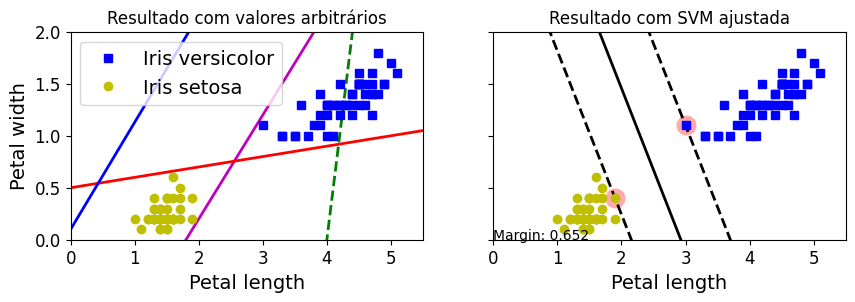

In [ ]:
# Criando função para plotar as fronteiras de classificacao (vetor de suporte e hiperplano de suporte)
def plot_svc_decision_boundary(svm_clf, xmin, xmax):
    import numpy as np
    w = svm_clf.coef_[0] # coeficiente de inclinação do plano
    b = svm_clf.intercept_[0] # bias: deslocamento do eixo em relação ao 0 do hiperplano

    # Na fronteira de decisao, w0*x0 + w1*x1 + b = 0
    # Hiperplano de decisao => x1 = -w0/w1 * x0 - b/w1
    x0 = np.linspace(xmin, xmax, 200)
    decision_boundary = -w[0]/w[1] * x0 - b/w[1] # montagem da equação

    margin = 1/w[1] # para efeito visual, definição do tamanho da margem
    margin_dist = 1/np.linalg.norm(w,2) # definição do tamanho da margem real do algoritmo

    gutter_up = decision_boundary + margin # margem superior
    gutter_down = decision_boundary - margin # margem inferior

    # plotagem dos resultados
    svs = svm_clf.support_vectors_
    plt.scatter(svs[:, 0], svs[:, 1], s=180, facecolors='#FFAAAA') #identifica os pontos do vetor de suporte
    plt.plot(x0, decision_boundary, "k-", linewidth=2) #hiperplano de suporte (fronteira de decisão)
    plt.plot(x0, gutter_up, "k--", linewidth=2) # vetor de suporte +1
    plt.plot(x0, gutter_down, "k--", linewidth=2) # vetor de suporte -1
    plt.annotate('Margin: {}'.format(round(margin_dist,3)),(xmin,xmin)) #exibe o valor da margem de separação (tamanho da margem em número)

# Criando retas de classificacao para o espaco de caracteristicas (3 diferentes valores para serem inseridos nos espaços, para verificação do comportamento de cada uma)
x0 = np.linspace(0, 5.5, 200)
pred_1 = 5*x0 - 20
pred_2 = x0 - 1.8
pred_3 = 0.1 * x0 + 0.5
pred_4 = 1.03 *x0 + 0.1

# Configurando a figura com subplots
fig, axes = plt.subplots(ncols=2, figsize=(10,2.7), sharey=True) # sharey -> compartilhar eixo y

plt.sca(axes[0]) # subplot 0 - retas pred_1, pred_2 e pred_3 (arbitrarias)
plt.plot(x0, pred_1, "g--", linewidth=2) # reta verde tracejada - aleatoria, que não separa os grupos
plt.plot(x0, pred_2, "m-", linewidth=2) # reta magenta continua - separa os grupos
plt.plot(x0, pred_3, "r-", linewidth=2) # reta vermelha continua - separa os grupos
plt.plot(x0, pred_4, "b-", linewidth=2) # reta azul, não separou nada
plt.title("Resultado com valores arbitrários")
plt.plot(X[:, 0][Y==1], X[:, 1][Y==1], "bs", label="Iris versicolor")
plt.plot(X[:, 0][Y==0], X[:, 1][Y==0], "yo", label="Iris setosa")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 5.5, 0, 2])

# Com dados ajustados
plt.sca(axes[1]) # subplot 1 - Classificador SVM linear (ajustado)
plot_svc_decision_boundary(svm_clf, 0, 5.5)
plt.plot(X[:, 0][Y==1], X[:, 1][Y==1], "bs")
plt.plot(X[:, 0][Y==0], X[:, 1][Y==0], "yo")
plt.title("Resultado com SVM ajustada")
plt.xlabel("Petal length", fontsize=14)
plt.axis([0, 5.5, 0, 2])


plt.show()

# **1.5 Como as escalas do banco de dados influenciam na otimização da SVM**

(np.float64(-2.0), np.float64(2.0), np.float64(-2.0), np.float64(2.0))

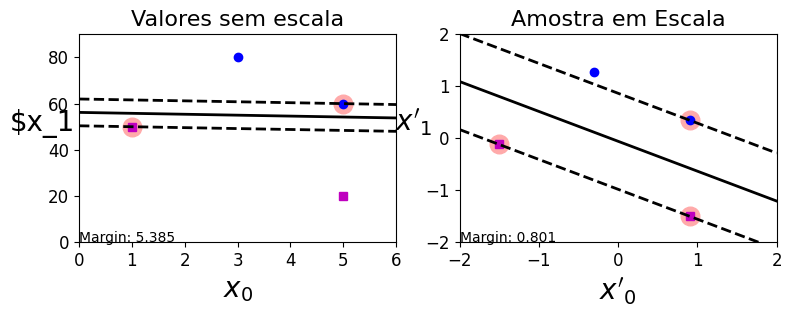

In [ ]:
# conjunto de dados para testar se a escala dos dados influenciam na decisão do SVM
# não será usada a base iris. É apenas uma base de teste, com coordenadas arbitrárias

# Dois grupos diferentes
Xs = np.array([[1, 50], [5, 20], [3, 80], [5, 60]]).astype(np.float64) # as coordenadas das amostras
ys = np.array([0, 0, 1, 1]) # as classes das amostras, classe 0 e 1
svm_clf = SVC(kernel="linear", C=100) # Aplicação de uma SVM de Kernel linear, com custo 100
svm_clf.fit(Xs, ys) # Aqui o modelo é treinado, repassando os dados de entrada e de saída.

# Plotagem do resultado
plt.figure(figsize=(9,2.7))
plt.subplot(121)
plt.plot(Xs[:, 0][ys==1], Xs[:, 1][ys==1], "bo")
plt.plot(Xs[:, 0][ys==0], Xs[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, 0, 6)
plt.xlabel("$x_0$", fontsize=20)
plt.ylabel("$x_1", fontsize=20, rotation=0)
plt.title("Valores sem escala", fontsize=16)
plt.axis([0, 6, 0, 90])

# processo de Padronização, para colocar a amostra em média 0 e desvio padrão 1
from sklearn.preprocessing import StandardScaler # Da biblioteca sklearn (biblioteca de pre c importamos o StandardScaler
scaler = StandardScaler() # Jogamos em uma variável
X_scaled = scaler.fit_transform(Xs) # Tranforma os dados (padroniza)  Xs
svm_clf.fit(X_scaled, ys) # Executa uma SVM mas com dados padronizados

# Plotagem dos dados padronizados pela SVM
plt.subplot(122)
plt.plot(X_scaled[:, 0][ys==1], X_scaled[:, 1][ys==1], "bo")
plt.plot(X_scaled[:, 0][ys==0], X_scaled[:, 1][ys==0], "ms")
plot_svc_decision_boundary(svm_clf, -2, 2)
plt.xlabel("$x'_0$", fontsize=20)
plt.ylabel("$x'_1$  ", fontsize=20, rotation=0)
plt.title("Amostra em Escala", fontsize=16)
plt.axis([-2, 2, -2, 2])

- A saída com os valores sem escala mostram valores distantes entre si, dadas as coordenadas arbi*trarias escolhidas.
- A saida em escla mostra que quanto mais próximos de 1 forem os dados, melhor será a classificação. **A SVM é sensível à escala dos dados**.



# **AULA 2 - SVM Lineares de Margens Suaves**

------------------------------------------------------------------------------------------------------------------
------------------------------------------------------------------------------------------------------------------

# **2.1 Modelo ajustado com outliers**

- SVM de margens suaves vão aceitar, com algum custo, que algumas amostras sejam classificadas de forma errada, com a intenção de manter um certo tamanho das margens de separação no hiperplano de separação e os vetores de suporte
- Usaremos o dataset do iris e inseriremos alguns outliers, amostras de classes especificas mas dentro de um intervalo diferente do original;


In [ ]:
# Inserindo outliers no espaco de caracteristicas do dataset iris
X_outliers = np.array([[3.4, 1.3], [2, 1.5]]) # amostras fora do intervalo original
y_outliers = np.array([0, 0])

#X_outliers = np.array([[2.5,1.5]]) # pedido pelo exercicio
#y_outliers = np.array([0]) #setosa

# Concatenando os dados dos outliers aos dados do problema
# estes dados evidenciarão os problemas causados por outliers
Xo1 = np.concatenate([X, X_outliers[:1]], axis=0)
yo1 = np.concatenate([Y, y_outliers[:1]], axis=0)
Xo2 = np.concatenate([X, X_outliers[1:]], axis=0)
yo2 = np.concatenate([Y, y_outliers[1:]], axis=0)

#Xo3 = np.concatenate([X, X_outliers], axis=0)
#yo3 = np.concatenate([y, y_outliers], axis=0)



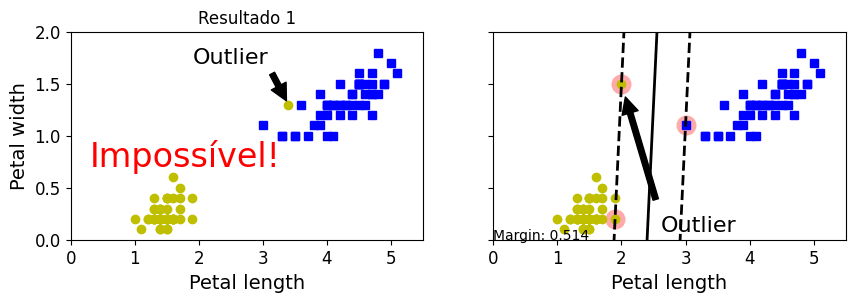

In [ ]:
# Criando e ajustando o modelo de SVM linear de margem rígida
svm_clf2 = SVC(kernel="linear", C=100)
svm_clf2.fit(Xo2, yo2) # Modelo sendo ajustado

fig, axes = plt.subplots(ncols=2, figsize=(10,2.7), sharey=True)

plt.sca(axes[0])
plt.title("Resultado 1")
plt.plot(Xo1[:, 0][yo1==1], Xo1[:, 1][yo1==1], "bs")
plt.plot(Xo1[:, 0][yo1==0], Xo1[:, 1][yo1==0], "yo")
plt.text(0.3, 0.7, "Impossível!", fontsize=24, color="red")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.annotate("Outlier",
             xy=(X_outliers[0][0], X_outliers[0][1]),
             xytext=(2.5, 1.7),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.1),
             fontsize=16,
            )
plt.axis([0, 5.5, 0, 2])

plt.sca(axes[1])
plt.plot(Xo2[:, 0][yo2==1], Xo2[:, 1][yo2==1], "bs")
plt.plot(Xo2[:, 0][yo2==0], Xo2[:, 1][yo2==0], "yo")
plot_svc_decision_boundary(svm_clf2, 0, 5.5)
plt.xlabel("Petal length", fontsize=14)
plt.annotate("Outlier",
             xy=(X_outliers[1][0], X_outliers[1][1]),
             xytext=(3.2, 0.08),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.1),
             fontsize=16,
            )
plt.axis([0, 5.5, 0, 2])

plt.show()

- No Resultado 1, não é possível traçar uma margem rígida para separar o outlier. A amostra é classificada de modo errado.

# **2.2 Ajustando uma SVM de margens suaves**

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline # biblioteca para executar sequencia de codigos repetitivos, para ajustar o modelo
from sklearn.preprocessing import StandardScaler # escalonamento de padronização
from sklearn.svm import LinearSVC # Kernel linear

iris = datasets.load_iris()
X = iris["data"][:, (2, 3)]  # petal length, petal width
y = (iris["target"] == 2).astype(np.float64)  # Iris virginica, grupo não linearmente separável ( todos do tipo 2)

svm_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("linear_svc", LinearSVC(C=1, loss="hinge", random_state=42)), # random é inicializador aleatório
    ])

svm_clf.fit(X, y) # ajuste do modelo, que será ajusrtado na ordem oferecida pelo pipeline

Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge', random_state=42))])

In [ ]:
# Testando a classificacao de uma amostra na SVM
svm_clf.predict([[5.5, 1.7]]) # predição arbitraria, que foi clasificada como 1

array([1.])

# **2.3 Testando SVMs de margens suaves com diferentes constantes de violação (custo) C**

Agora testaremos a SVM de margem suave para diferentes custos (quanto maior o custo, mais próximo de uma SVM de amrgem rígidas nos estamos. Com custo baixo o modelo aceita amostras erradas, mas deixa maior margem de separação no hiperplano do espaço amostral

In [ ]:
# Configurando diferentes SVMs de margens suaves, com C = 1 e C = 100
scaler = StandardScaler()
svm_clf1 = LinearSVC(C=1, loss="hinge", random_state=42) # funcao de perda do classificador
svm_clf2 = LinearSVC(C=10000, loss="hinge", random_state=42) # loss = 'hinge' funciona melhor para o classificador linear

#Pipeline de transformacoes em cada uma
scaled_svm_clf1 = Pipeline([
        ("scaler", scaler),
        ("linear_svc", svm_clf1),
    ])
scaled_svm_clf2 = Pipeline([
        ("scaler", scaler),
        ("linear_svc", svm_clf2),
    ])
# dois modelos diferentes serão ajustados
scaled_svm_clf1.fit(X, y)
scaled_svm_clf2.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc',
                 LinearSVC(C=10000, loss='hinge', random_state=42))])

In [ ]:
# Adaptando o modelo escalonado para preparar os plots

# Convertendo para parametros sem escalonamento
b1 = svm_clf1.decision_function([-scaler.mean_ / scaler.scale_])
b2 = svm_clf2.decision_function([-scaler.mean_ / scaler.scale_])
w1 = svm_clf1.coef_[0] / scaler.scale_
w2 = svm_clf2.coef_[0] / scaler.scale_
svm_clf1.intercept_ = np.array([b1])
svm_clf2.intercept_ = np.array([b2])
svm_clf1.coef_ = np.array([w1])
svm_clf2.coef_ = np.array([w2])

# Calculando os vetores de suporte
t = y * 2 - 1
support_vectors_idx1 = (t * (X.dot(w1) + b1) < 1).ravel()
support_vectors_idx2 = (t * (X.dot(w2) + b2) < 1).ravel()
svm_clf1.support_vectors_ = X[support_vectors_idx1]
svm_clf2.support_vectors_ = X[support_vectors_idx2]

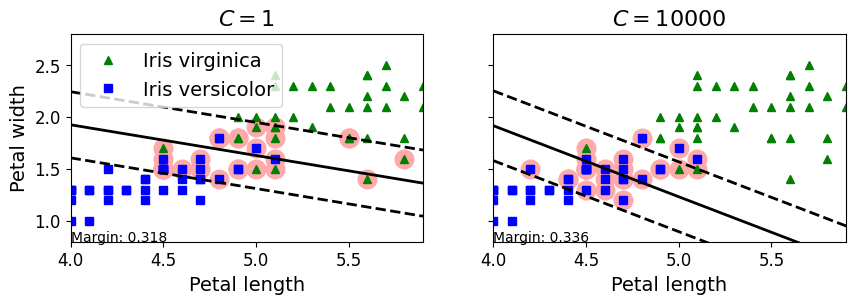

In [ ]:
# Plotando as figuras com diferentes valores de C
fig, axes = plt.subplots(ncols=2, figsize=(10,2.7), sharey=True)

plt.sca(axes[0])
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^", label="Iris virginica")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs", label="Iris versicolor")
plot_svc_decision_boundary(svm_clf1, 4, 5.9)
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.legend(loc="upper left", fontsize=14)
plt.title("$C = {}$".format(svm_clf1.C), fontsize=16)
plt.annotate('Margin: {}'.format(round(1/w1[1],3)),(4,0.8))
plt.axis([4, 5.9, 0.8, 2.8])

plt.sca(axes[1])
plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
plot_svc_decision_boundary(svm_clf2, 4, 5.99)
plt.xlabel("Petal length", fontsize=14)
plt.title("$C = {}$".format(svm_clf2.C), fontsize=16)
plt.annotate('Margin: {}'.format(round(1/w2[1],3)),(4,0.8))
plt.axis([4, 5.9, 0.8, 2.8])

plt.show()

- Temos uma SVM de margem suave com custo 1 e uma com custo 100
- Na SVM com c=1, a margem é maior (0.318cm), mas classifica muito mais amostras erradas. Não tem como separar os cinjuntos por margens rigidas
- Na SVM de custo 100, ele  deixa errar menos (5 amostras da versicolor).

# **Aula 03 - SVMs Não Lineares e as Funções Kernel**


# **3.1 SVM Não Lineares**

- Utilizadas quando o problema possui amostras não linearmente separáveis
- Utilizamos polinomios de diferentes graus, e funções de outras bases (como bases radiais)


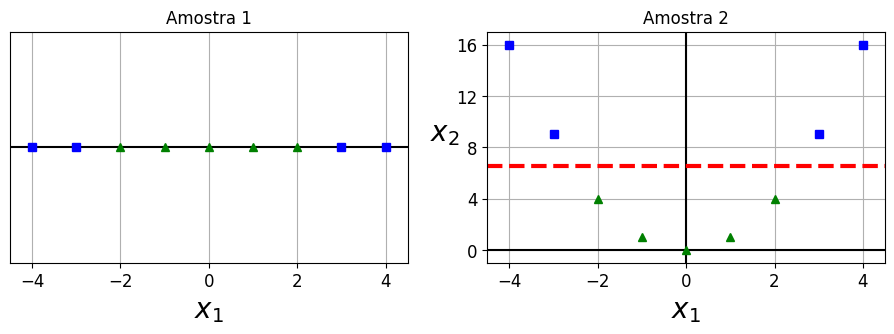

In [ ]:
X1D = np.linspace(-4, 4, 9).reshape(-1, 1)
X2D = np.c_[X1D, X1D**2]
y = np.array([0, 0, 1, 1, 1, 1, 1, 0, 0])

plt.figure(figsize=(10, 3))

plt.subplot(121)
plt.title("Amostra 1")
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.plot(X1D[:, 0][y==0], np.zeros(4), "bs")
plt.plot(X1D[:, 0][y==1], np.zeros(5), "g^")
plt.gca().get_yaxis().set_ticks([])
plt.xlabel(r"$x_1$", fontsize=20)
plt.axis([-4.5, 4.5, -0.2, 0.2])

plt.subplot(122)
plt.title("Amostra 2")
plt.grid(True, which='both')
plt.axhline(y=0, color='k')
plt.axvline(x=0, color='k')
plt.plot(X2D[:, 0][y==0], X2D[:, 1][y==0], "bs")
plt.plot(X2D[:, 0][y==1], X2D[:, 1][y==1], "g^")
plt.xlabel(r"$x_1$", fontsize=20)
plt.ylabel(r"$x_2$  ", fontsize=20, rotation=0)
plt.gca().get_yaxis().set_ticks([0, 4, 8, 12, 16])
plt.plot([-4.5, 4.5], [6.5, 6.5], "r--", linewidth=3)
plt.axis([-4.5, 4.5, -1, 17])

plt.subplots_adjust(right=1)

plt.show()

- As SVM Nâo lieares permitem interpretar a amostra de forma não linear, por emio de algum tipo de função;
Em **Amostra 1**, temos uma amostra que possui somente uma coordenada, com a distribuição da maostra começando com amostras  de uma classe, muda no meio e volta a ser da classe anterior. Não tem como separar este espaço amostral utilizando somente esta coordenada.
- Para isso, aplicamos uma  SVM Não Linear ou alteramos a função Kernel, de forma a permitir que se almente ou se modifique o espaço amostral, de modo a permitir que se possa separar omespaço (como em **Amostra 2**)

# 3.2 Espaço Polinomial e Dataset Make-Moons

Vamos trabalhar com um dataset artificial, criado a partir de valores aleatórios, que podem ser controlados, o make_moons (que se encontra no sklearn). Depois, utlizaremos esa amostra para classificar esse banco de dados com SVM Não Lineares e Kerneks.

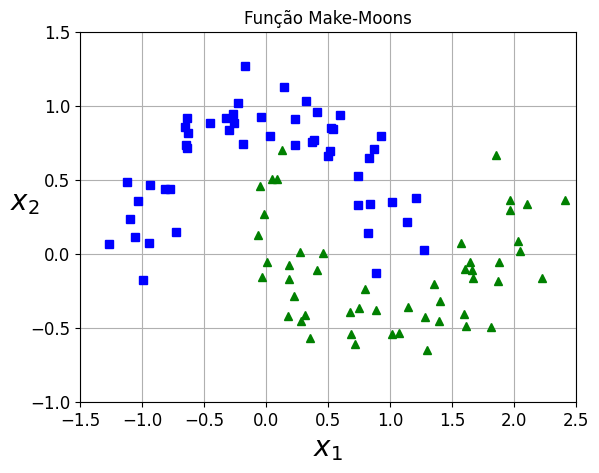

In [ ]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=100, noise=0.15, random_state=42) # o noise acrescenta oa mistura na amostra, em estado 42 de mistura)

# função de plotagem
def plot_dataset(X, y, axes):
    plt.title("Função Make-Moons")
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True, which='both')
    plt.xlabel(r"$x_1$", fontsize=20)
    plt.ylabel(r"$x_2$", fontsize=20, rotation=0)

plot_dataset(X, y, [-1.5, 2.5, -1, 1.5]) # Limite do espaço amostral
plt.show()

Vamos utilizar uma SVM não linear com função Kernel polinomial de terceiro grau para tentar separar o espaço de características e mostrar como o hiperplano não linear classificará as amostras.

In [ ]:
from sklearn.datasets import make_moons # importou o make-moons
from sklearn.pipeline import Pipeline # importou o pipeline para fazer o modelo de forma sequencial e estruturada
from sklearn.preprocessing import PolynomialFeatures # Para trabalhar as features do problema

polynomial_svm_clf = Pipeline([
        ("poly_features", PolynomialFeatures(degree=200)), # utilizamos features polinomiais de grau 200
        ("scaler", StandardScaler()), # Padronizar em média 0 (todos no mesmo intervalo)
        ("svm_clf", LinearSVC(C=100, loss="hinge", random_state=42)) # classificação linear com custo 10
    ])
# ENTÃO: TRANSFORMAMSO O PROBLEMA DE MAKE-MOONS E PEDIMOS PARA QUE ELE SEJA INTERPRETADO POR UM POLINOMIO DE GRAU 200.
# SAIMOS DE UM ESPAÇO DE DIMENSÃO 2 PARA UM ESPAÇO DE DIMENSÃO 200
polynomial_svm_clf.fit(X, y)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=200)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=100, loss='hinge', random_state=42))])

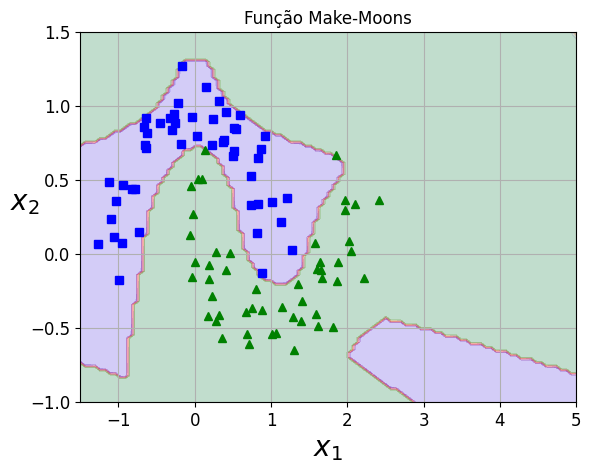

In [ ]:
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(polynomial_svm_clf, [-1.5, 5, -1, 1.5])
plot_dataset(X, y, [-1.5, 5, -1, 1.5])

plt.show()

- Naõ temos mais retas. O modelo vai traçar linhas baseado nas 200 dimensões. No ajuste o modelo separeou as duas classes, de modo eficiente. Possui algumas amostras de fronteira.


- Tudo que está abaixo da linha vermelha será classificado como triângulo e tudo que está acima, quadrado. Repare que devido à constante C ter um valor pequeno, algumas amostras são classificadas de maneira errada.

# **3.3 SVM não linear com função Kernel Gaussiana (RBF - Radial Based Function)**


In [ ]:
from sklearn.svm import SVC

gamma1, gamma2 = 0.1, 5 # parametro gamma será o raio da função radial. Quanto maior, mario será a bola qu separará o conjunto
C1, C2 = 0.001, 1000 # margem de custo muito suave (0.001), e uma margem de custo maior (1000)
hyperparams = (gamma1, C1), (gamma1, C2), (gamma2, C1), (gamma2, C2) # hiperparametros de fora do modelo, que serão ajustadoos de forma recorrente

svm_clfs = []
for gamma, C in hyperparams:
    rbf_kernel_svm_clf = Pipeline([ # criará dierente svm de clasificação
            ("scaler", StandardScaler()), # padronização
            ("svm_clf", SVC(kernel="rbf", gamma=gamma, C=C)) # Pedindo o Kernel rbf - radial based function
        ])
    rbf_kernel_svm_clf.fit(X, y) # ajusta o modelo
    svm_clfs.append(rbf_kernel_svm_clf) # coloca dentro do rbf

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10.5, 7), sharex=True, sharey=True)

 # plotar os classificadores
for i, svm_clf in enumerate(svm_clfs):
    plt.sca(axes[i // 2, i % 2])
    plot_predictions(svm_clf, [-1.5, 2.45, -1, 1.5])
    plot_dataset(X, y, [-1.5, 2.45, -1, 1.5])
    gamma, C = hyperparams[i]
    plt.title(r"$\gamma = {}, C = {}$".format(gamma, C), fontsize=16)
    if i in (0, 1):
        plt.xlabel("")
    if i in (1, 3):
        plt.ylabel("")

plt.show()

O termo gamma é inversamente proporcional ao desvio padrão da função gaussiana,

\begin{equation}
\gamma~\alpha~\frac{1}{\sigma}.
\end{equation}

Sendo assim, quanto maior o *gamma*, mais próximo das amostras a função gaussiana de estará das amostras.

- Caso 1: Gamma baixo (função radial) e custo baixo: grandes erros de classificação
- CAso 2: Gamma baixo e custo alto: o raio varia muito e dimunui o erro, mas o espaço é irrestrito
- Caso 3: aumentando o gamma a classificação se trona mais precisa. O modelo cria ilhas onde o que está fora é verde e o que está dentro e azul. Mas ainda tem amostras classificadas incorretamente.
- Caso 4: aumento das duas variáveis cria ilha de forma mai restrita, não tem mais amostras erradas.